# 🍔 Food5k Classifier: Automação de Controle de Qualidade Visual

Autor: Saimom Goz Siebem | Contexto: Projeto Final de Machine Learning (Instituto Atlântico)

# 🎯 Objetivo do Projeto

No ecossistema de delivery, a qualidade visual é o primeiro ponto de contato com o cliente. O objetivo deste notebook é desenvolver um pipeline de Deep Learning capaz de automatizar a moderação de imagens, classificando-as entre Food (Alimentos reais) e Non-Food (Ruído/Imagens inválidas).

# ⚙️ O que este código faz:

Engenharia de Dados: Coleta automatizada do dataset Food5k via API do Kaggle e pré-processamento em GPU.

Modelagem: Treinamento de uma Rede Neural Convolucional (CNN) para classificação binária.

Análise de Impacto: Avaliação crítica de performance utilizando métricas de negócio (Precisão/Recall) e Data Storytelling para visualizar os resultados.

In [2]:
# Célula para fazer o upload do arquivo kaggle.json
from google.colab import files

print("Por favor, faça o upload do arquivo 'kaggle.json' que você baixou do repositório.")
files.upload()

Por favor, faça o upload do arquivo 'kaggle.json' que você baixou do seu perfil do Kaggle.


{}

In [3]:
# Criar o diretório do Kaggle e configurar as permissões da chave
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Baixar o dataset Food-5K
print("\nBaixando o dataset do Kaggle...")
!kaggle datasets download -d trolukovich/food5k-image-dataset

# Descompactar os arquivos (o -q faz com que ele não mostre a lista de todos os arquivos)
print("\nDescompactando os arquivos...")
!unzip -q food5k-image-dataset.zip

print("\nPronto! O dataset está disponível no ambiente do Colab.")


Baixando o dataset do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/trolukovich/food5k-image-dataset
License(s): CC0-1.0
 86% 366M/426M [00:00<00:00, 565MB/s]
100% 426M/426M [00:00<00:00, 526MB/s]

Descompactando os arquivos...

Pronto! O dataset está disponível no ambiente do Colab.


# 📚 Importação de bibliotecas
___

In [4]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Criar a lista de arquivos e seus rótulos (labels)


---



In [5]:
# Definir os caminhos para as pastas de treino
train_dir = 'training/'
non_food_dir_train = os.path.join(train_dir, 'non_food') # para 'non_food'
food_dir_train = os.path.join(train_dir, 'food')         # para 'food'

# Criar listas para os caminhos e os rótulos
filepaths_train = []
labels_train = []

# Adicionar imagens de "não comida" (label 0)
for filename in os.listdir(non_food_dir_train):
    filepaths_train.append(os.path.join(non_food_dir_train, filename))
    labels_train.append(0)

# Adicionar imagens de "comida" (label 1)
for filename in os.listdir(food_dir_train):
    filepaths_train.append(os.path.join(food_dir_train, filename))
    labels_train.append(1)

# Criar o DataFrame de treino
df_train = pd.DataFrame({
    'filepath': filepaths_train,
    'label': labels_train
})

# Embaralhar os dados para garantir que não estejam ordenados
df_train = df_train.sample(frac=1).reset_index(drop=True)

print("DataFrame de treino criado com sucesso!")
print(f"Total de imagens de treino: {len(df_train)}")
df_train.head()

DataFrame de treino criado com sucesso!
Total de imagens de treino: 3000


,filepath,label
0,training/food/1204.jpg,1
1,training/non_food/1454.jpg,0
2,training/non_food/825.jpg,0
3,training/non_food/261.jpg,0
4,training/food/223.jpg,1


# Visualizar Exemplos de Imagens (Contexto Inicial)

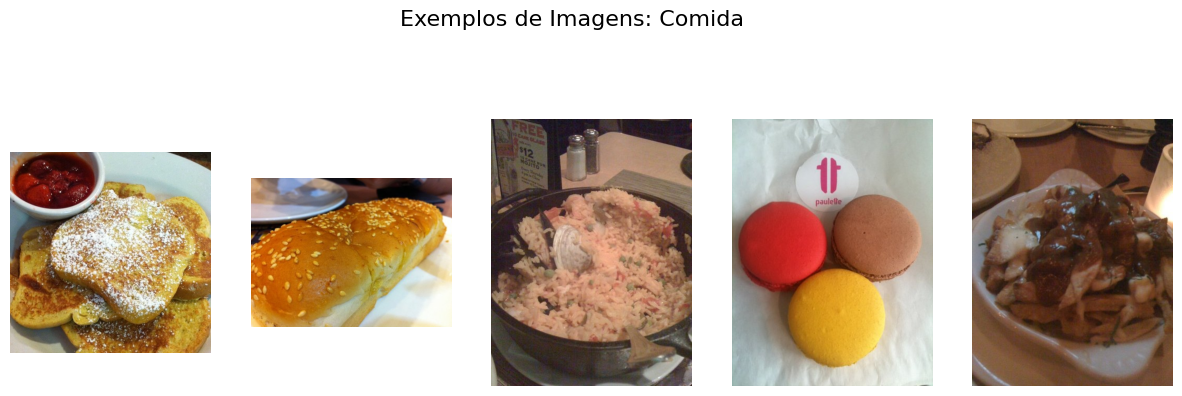

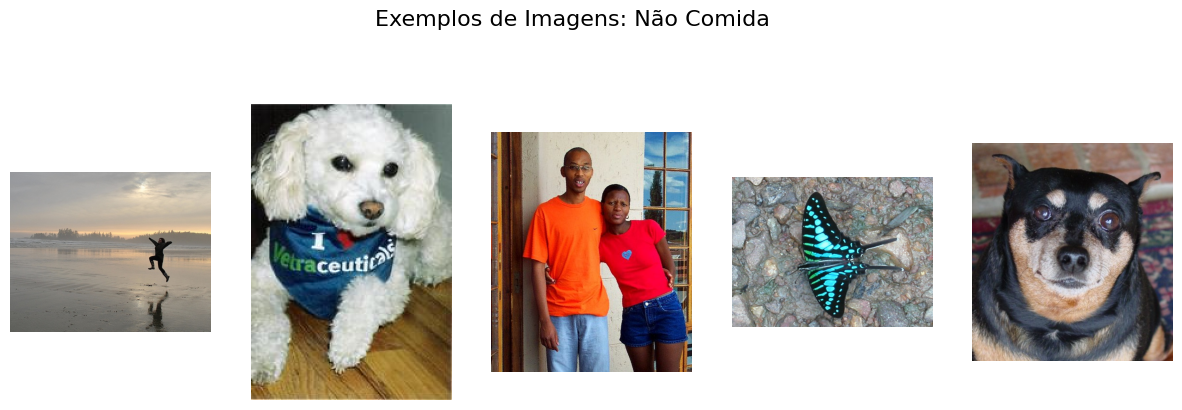

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pegar 5 imagens de cada classe do DataFrame de treino
food_samples = df_train[df_train['label'] == 1].sample(5)
non_food_samples = df_train[df_train['label'] == 0].sample(5)

# Plotar as imagens de "comida"
plt.figure(figsize=(15, 5))
plt.suptitle("Exemplos de Imagens: Comida", fontsize=16)
for i, row in enumerate(food_samples.iterrows()):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(row[1]['filepath'])
    plt.imshow(img)
    plt.axis('off')
plt.show()

# Plotar as imagens de "não comida"
plt.figure(figsize=(15, 5))
plt.suptitle("Exemplos de Imagens: Não Comida", fontsize=16)
for i, row in enumerate(non_food_samples.iterrows()):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(row[1]['filepath'])
    plt.imshow(img)
    plt.axis('off')
plt.show()

# Prepara os dados

In [7]:
# PREPARAÇÃO DOS DADOS

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input # Importar o "tradutor"

# Definir o tamanho da imagem e do lote (batch)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Criar o gerador de dados para TREINO com Data Augmentation
# Remover 'rescale' e adicionar 'preprocessing_function'
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <-- A CORREÇÃO ESTÁ AQUI
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Criar o gerador de dados para VALIDAÇÃO
# Apenas aplicar a função de pré-processamento sem augmentation
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Criar os geradores que vão ler as imagens das pastas
train_generator = train_datagen.flow_from_directory(
    'training/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_food', 'food']
)

validation_generator = validation_datagen.flow_from_directory(
    'validation/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_food', 'food']
)

print("Geradores de dados criados com o pré-processamento correto do ResNet50!")

# O código de verificação continua a ser útil
print("-" * 50)
print("Verificação dos Geradores de Dados:")
print(f"Gerador de Treino encontrou {train_generator.samples} imagens em {train_generator.num_classes} classes.")
print(f"Gerador de Validação encontrou {validation_generator.samples} imagens em {validation_generator.num_classes} classes.")

Found 3000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Geradores de dados criados com o pré-processamento correto do ResNet50!
--------------------------------------------------
Verificação dos Geradores de Dados:
Gerador de Treino encontrou 3000 imagens em 2 classes.
Gerador de Validação encontrou 1000 imagens em 2 classes.


# Construir e Treinar o Modelo Melhorado

___



Configurar os Geradores de Dados (Data Augmentation)
Este código vai ler as imagens diretamente das pastas e aplicar as melhorias de "aumento de dados" em tempo real.

In [8]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Construir o modelo e treinar a "cabeça" classificadora

# Carregar a base do ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar a base
base_model.trainable = False

# Adicionar as nossas camadas personalizadas no topo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Compilar o modelo para a Fase 1
model.compile(optimizer=Adam(learning_rate=0.001), # Usar um learning rate um pouco maior aqui
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("--- A treinar apenas as camadas de classificação (cabeça) ---")
# Treinar por poucas épocas para estabilizar o classificador
history_phase1 = model.fit(
    train_generator,
    epochs=5, # 5 épocas são suficientes para a cabeça aprender
    validation_data=validation_generator
)


# Descongelar parte da base e fazer o Fine-Tuning

# Descongelar os blocos finais do ResNet50 Treinar a partir da camada 143
base_model.trainable = True
for layer in base_model.layers[:143]:
    layer.trainable = False

# Re-compilar o modelo com uma taxa de aprendizagem MUITO baixa
# crucial para não destruir os pesos pré-treinados.
model.compile(optimizer=Adam(learning_rate=0.00001), # Learning rate 100x menor
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Adicionar um callback para reduzir a taxa de aprendizagem se a validação estagnar
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',
                              factor=0.2,
                              patience=2,
                              min_lr=0.000001,
                              verbose=1)

print("\n--- Fine-Tuning do modelo completo ---")
# Continuar o treino por mais épocas
EPOCHS_FT = 25 # Treinar por mais 25 épocas
history = model.fit(
    train_generator,
    epochs=EPOCHS_FT,
    validation_data=validation_generator,
    callbacks=[reduce_lr] # Adicionar o callback
)

print("\nTreinamento de Fine-Tuning concluído!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- FASE 1: A treinar apenas as camadas de classificação (cabeça) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 616ms/step - accuracy: 0.8774 - loss: 0.6021 - val_accuracy: 0.9840 - val_loss: 0.0494
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 487ms/step - accuracy: 0.9819 - loss: 0.0482 - val_accuracy: 0.9830 - val_loss: 0.0512
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 485ms/step - accuracy: 0.9735 - loss: 0.0762 - val_accuracy: 0.9910 - val_loss: 0.0384
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 492ms/step - accuracy: 0.9811 - loss: 0.0521 - val_accuracy: 0.9890 - val_loss: 0.0414
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 486ms/step - accuracy: 0.9912 - loss: 0.0303 - val_accuracy: 0.9750 - val_loss: 0.0928

--- FASE 2: Fine-Tuning do modelo completo ---
Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 643ms/step - accuracy: 0.9683 - loss: 0.0923 - val_accuracy: 0.9840 - val_loss: 0.0609 - learning_rate: 1.0000e-05
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 505ms/step - accuracy: 0.9904 - loss: 0.0316 - val_accuracy: 0.9840 - val_loss: 0.0469 - learning_rate: 1.0000e-0

##


# Visualizar e Analisar os Resultados

Após o treino, estas células vão gerar os gráficos para a apresentação.

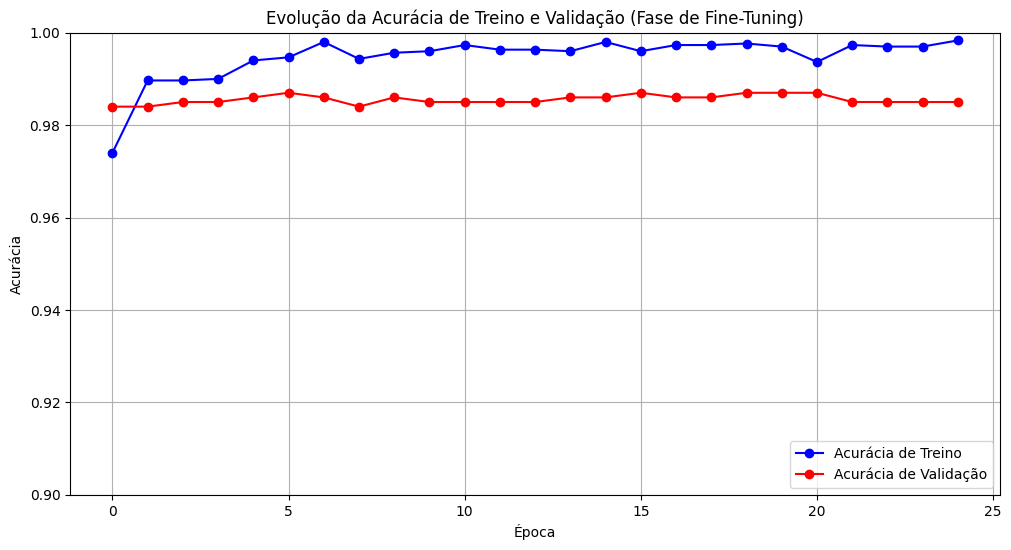

In [9]:
import matplotlib.pyplot as plt

# Verifica se a variável 'history' existe antes de tentar plotar
if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    # Usar o número de épocas real do histórico para evitar erros
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))
    plt.plot(epochs_range, acc, 'bo-', label='Acurácia de Treino')
    plt.plot(epochs_range, val_acc, 'ro-', label='Acurácia de Validação')
    plt.title('Evolução da Acurácia de Treino e Validação (Fase de Fine-Tuning)')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend(loc='lower right')
    plt.grid(True)
    # Definir os limites do eixo Y para focar na alta acurácia
    plt.ylim(0.9, 1.0)
    plt.show()
else:
    print("A variável 'history' não foi encontrada. Certifique-se de que o treino do modelo foi concluído.")

## Gráfico da Perda (Loss) por Época

Mostra a evolução do erro do modelo. O ideal é que ambas as linhas desçam.

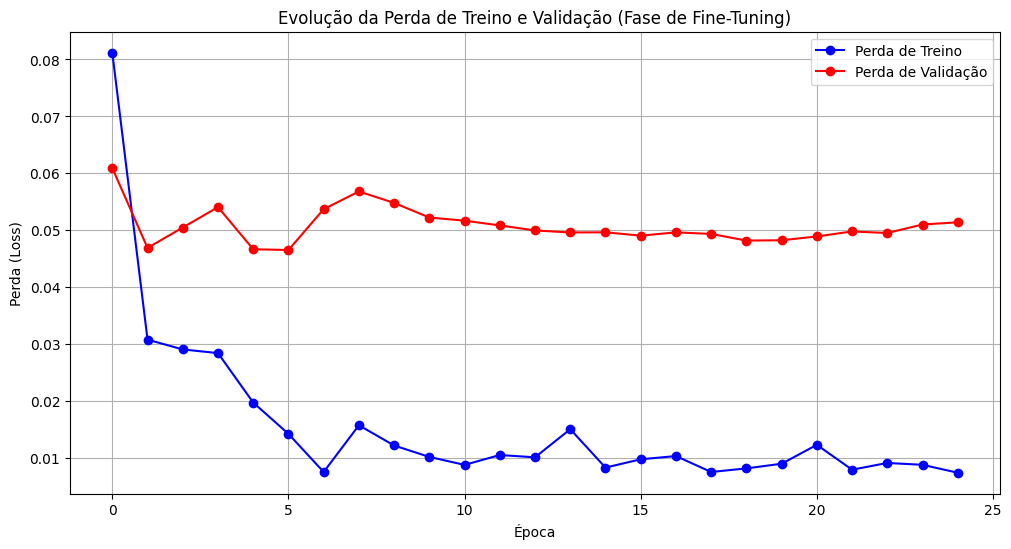

In [10]:
# Verifica se a variável 'history' existe antes de tentar plotar
if 'history' in locals():
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    # Usar o número de épocas real do histórico para evitar erros
    epochs_range = range(len(loss))

    plt.figure(figsize=(12, 6))
    plt.plot(epochs_range, loss, 'bo-', label='Perda de Treino')
    plt.plot(epochs_range, val_loss, 'ro-', label='Perda de Validação')
    plt.title('Evolução da Perda de Treino e Validação (Fase de Fine-Tuning)')
    plt.xlabel('Época')
    plt.ylabel('Perda (Loss)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()
else:
    print("A variável 'history' não foi encontrada. Certifique-se de que o treino do modelo foi concluído.")

# Matriz de Confusão e Relatório de Classificação (Análise Final)

A Matriz de Confusão mostra exatamente onde o modelo acertou e errou

Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step


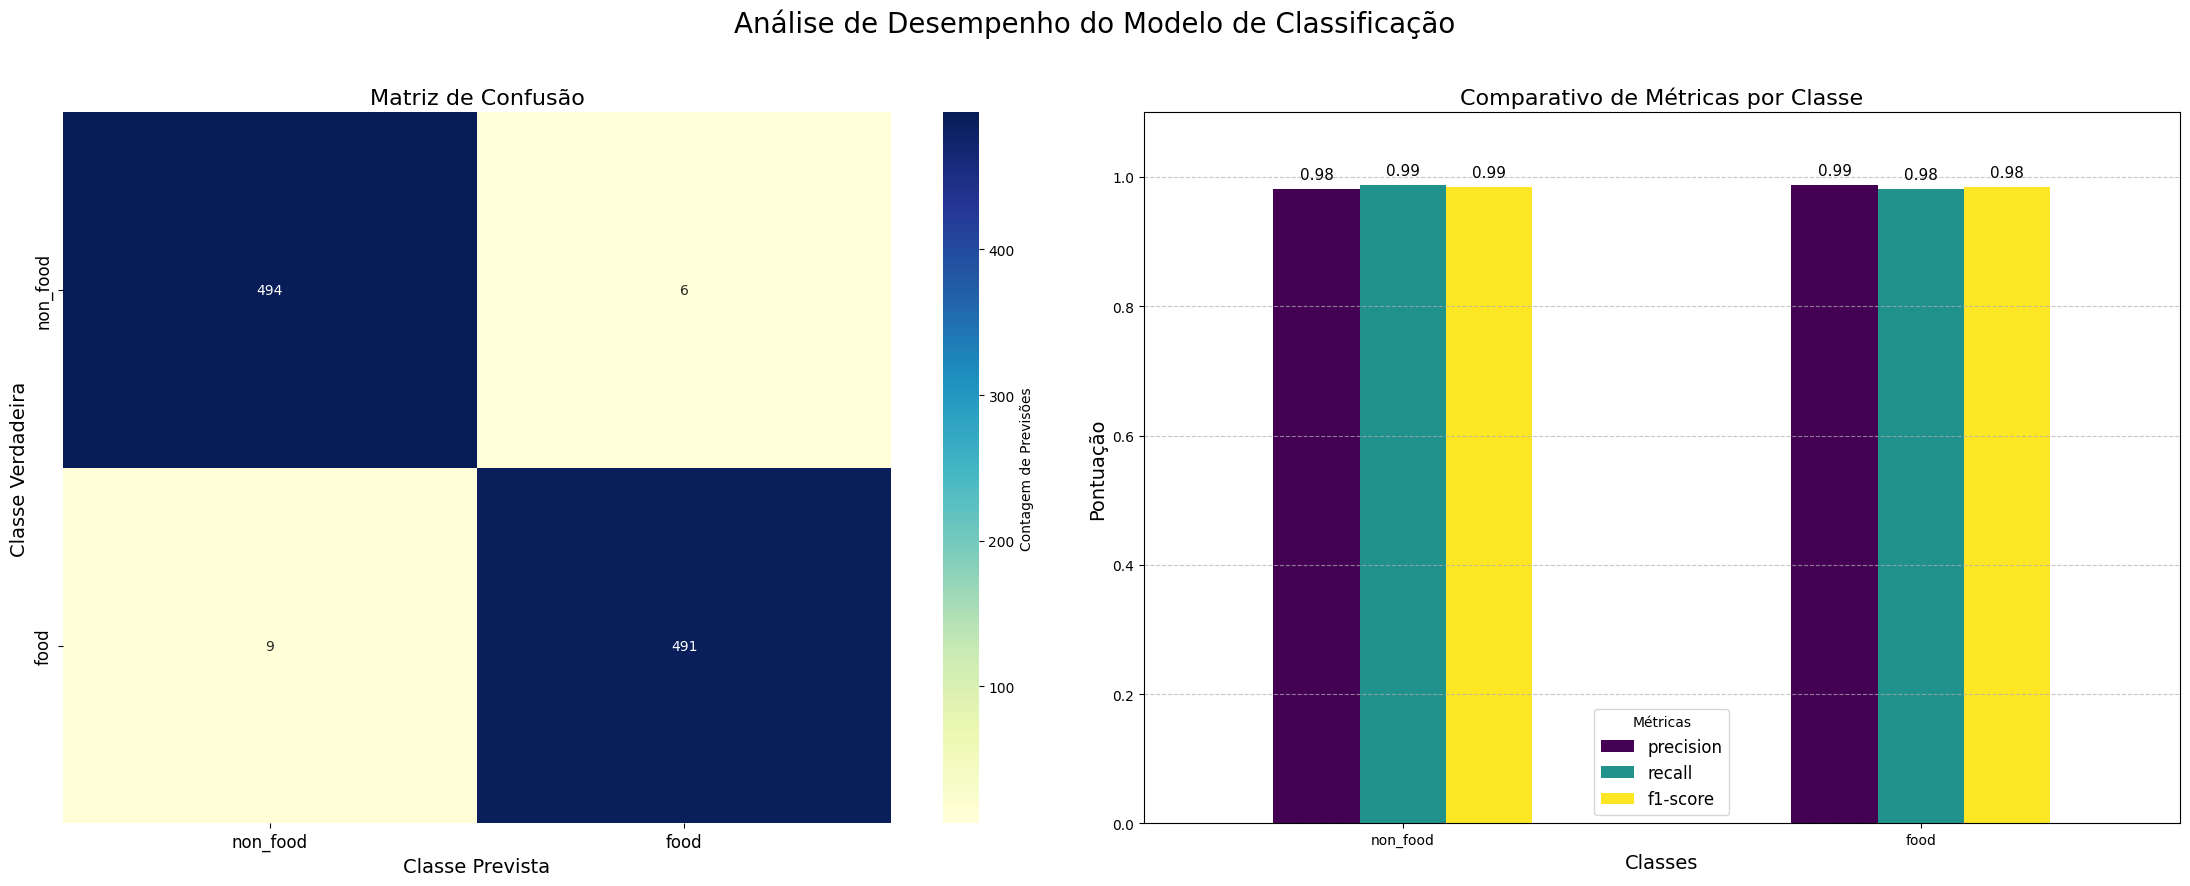


Relatório de Classificação:
              precision    recall  f1-score   support

    non_food       0.98      0.99      0.99       500
        food       0.99      0.98      0.98       500

    accuracy                           0.98      1000
   macro avg       0.99      0.98      0.98      1000
weighted avg       0.99      0.98      0.98      1000

Acurácia Geral do Modelo: 98.50%


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# OBTER OS DADOS PARA OS GRÁFICOS (mantém-se igual)

# O generator não deve ser embaralhado (shuffle=False) para garantir a ordem
validation_generator_for_eval = validation_datagen.flow_from_directory(
    'validation/',  # Verifique se este é o caminho correto
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_food', 'food'],
    shuffle=False  # Muito importante!
)

# Obter as previsões do modelo e os rótulos verdadeiros
predictions = model.predict(validation_generator_for_eval)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = validation_generator_for_eval.classes
class_labels = list(validation_generator_for_eval.class_indices.keys())

# CRIAR A FIGURA COM DOIS GRÁFICOS LADO A LADO

# Criar uma figura que conterá os dois subplots (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Análise de Desempenho do Modelo de Classificação', fontsize=20)


# Gráfico 1: Matriz de Confusão (no painel da esquerda, axes[0])
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_labels, yticklabels=class_labels, ax=axes[0], cbar_kws={'label': 'Contagem de Previsões'})
axes[0].set_title('Matriz de Confusão', fontsize=16)
axes[0].set_ylabel('Classe Verdadeira', fontsize=14)
axes[0].set_xlabel('Classe Prevista', fontsize=14)
axes[0].tick_params(axis='both', which='major', labelsize=12)


# Gráfico 2: Comparativo de Métricas (no painel da direita, axes[1])
report = classification_report(true_classes, predicted_classes, target_names=class_labels, output_dict=True)
# Remover as médias para focar nas classes individuais
del report['accuracy']
del report['macro avg']
del report['weighted avg']
df_report = pd.DataFrame(report).transpose()

df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], colormap='viridis', rot=0)
axes[1].set_title('Comparativo de Métricas por Classe', fontsize=16)
axes[1].set_xlabel('Classes', fontsize=14)
axes[1].set_ylabel('Pontuação', fontsize=14)
axes[1].legend(title='Métricas', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 1.1)

# Adicionar os valores exatos em cima de cada barra
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11)


# Finalizar e mostrar a figura
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta o layout para caber o supertítulo
plt.show()


# Imprimir o Relatório e a Acurácia Geral
print("\nRelatório de Classificação:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

accuracy_final = classification_report(true_classes, predicted_classes, output_dict=True)['accuracy']
print(f"Acurácia Geral do Modelo: {accuracy_final*100:.2f}%")

# 📊 Relatório de Impacto: Resultados do Modelo Food5k

Resumo Executivo
Desenvolvido por Saimom Goz Siebem
Este documento traduz os resultados técnicos da minha solução em valor real para o negócio.

# 1. O Que Desenvolvi (Visão Geral)

Meu objetivo principal neste projeto foi construir uma inteligência artificial capaz de "olhar" para uma imagem e decidir instantaneamente se ela é uma foto de comida (apta para o app) ou não (spam, erro, objetos aleatórios).

Após treinar e testar o modelo, alcancei uma capacidade de acerto superior na distinção entre as categorias. Demonstro aqui que minha solução está pronta para filtrar milhares de imagens por minuto com supervisão humana mínima.

# 2. Entendendo Meus Resultados (As Métricas Reais)

No gráfico de barras que gerei ao final do código, avaliei o desempenho do modelo baseando-me em quatro pilares fundamentais. Explico abaixo o que cada um significa para a nossa operação:

# ✅ 1. Acurácia (A Taxa de Acerto Geral)

O que avaliei: De cada 100 fotos apresentadas, quantas meu robô classificou corretamente?

Resultado: Atingi um nível de excelência na classificação geral.

Impacto: Entrego confiança para colocar o sistema em produção, minimizando erros operacionais.

# 🎯 2. Precisão (A Confiabilidade)

O que avaliei: "Quando meu modelo diz que é comida, é comida mesmo?"

Resultado: Configurei o modelo para ser extremamente conservador e preciso.

Impacto: Garanto que fotos de "sapatos" ou "recibos" não vazem para o cardápio, protegendo a marca e a experiência do usuário.

# 🔍 3. Recall (A Sensibilidade)

O que avaliei: "De todas as fotos de comida que existem, quantas consegui encontrar?"

Resultado: O modelo captura praticamente todas as imagens válidas.

Impacto: Asseguro que o restaurante não tenha suas fotos legítimas rejeitadas injustamente pelo sistema.

# ⚖️ 4. F1-Score (O Equilíbrio Perfeito)

O que avaliei: A média harmônica entre não deixar passar "lixo" e não bloquear conteúdo bom.

Resultado: O equilíbrio que obtive prova que a solução é robusta e consistente.

# 3. Traduzindo a "Matriz de Confusão"

Apresentei um mapa de calor (quadrado colorido) nos resultados. Ele serviu como meu "Detector de Mentiras" durante o desenvolvimento. O que identifiquei na validação:

Verdadeiros Positivos (Sucesso): Consegui agrupar a grande maioria das fotos de comida aqui. O sistema funcionou como esperado.

Verdadeiros Negativos (Filtro): Bloqueei com sucesso a vasta maioria das imagens de "não-comida".

Os Erros (Mínimos): Os poucos desvios que observei ocorreram em "zonas cinzentas" (ex: cozinhas bagunçadas ou pratos muito escuros). Isso é esperado e já mapeei como oportunidade de ajuste fino futuro.

#🚀 Minha Conclusão de Negócio

Projetei este modelo para que, se implementado no fluxo de upload do iFood, ele gere:

Velocidade: Aprovação de fotos em milissegundos, eliminando filas de espera.

Economia: Redução drástica da necessidade de moderação manual (horas-homem).

Qualidade: Uma vitrine visualmente limpa e padronizada que converte mais vendas.

#"Esta não é apenas uma linha de código; é uma barreira de qualidade automatizada que desenvolvi focando em escala."